In [3]:
from sklearn.cluster import KMeans
import numpy as np

In [4]:
data = np.array([
    [1, 2], [1, 4], [1, 0],
    [10, 2], [10, 4], [10, 0]
])

# 「二つのグループに分けて」とAIに命令する
model = KMeans(n_clusters=2, random_state=0)

# 学習を実行
model.fit(data)

print(model.labels_)

[1 1 1 0 0 0]


In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# [年収（万円）, 年齢]
data = np.array([
    [300, 22], [320, 24], [280, 21], 
    [800, 52], [850, 55], [780, 50]
])

# 標準化を実行（単位の景況をなくす）
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

# 標準化後のデータでクラスタリング
model = KMeans(n_clusters=2, random_state=0)
model.fit(data_scaled)

# 結果表示
print("グループ分け結果：", model.labels_)

グループ分け結果： [1 1 1 0 0 0]


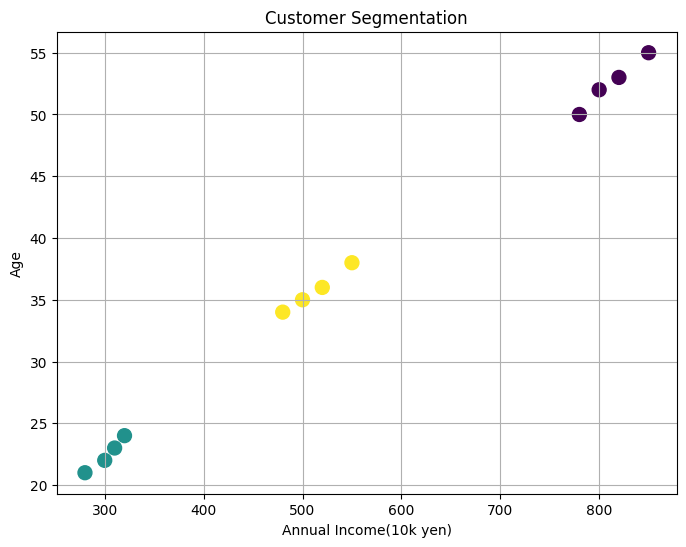

In [6]:
import matplotlib.pyplot as plt # グラフを描くための道具を用意

# データを準備　（年収[万円], 年齢）
data = np.array([
    [300, 22], [320, 24], [280, 21], [310, 23],
    [800, 52], [850, 55], [780, 50], [820, 53],
    [500, 35], [550, 38], [480, 34], [520, 36]
])

# 標準化
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

# K-Means　で3つのグループに分ける
model = KMeans(n_clusters=3, random_state=0)
labels = model.fit_predict(data_scaled)

# グラフに描画
plt.figure(figsize=(8, 6))

plt.scatter(data[:, 0], data[:, 1], c=labels, cmap="viridis", s=100)

plt.title("Customer Segmentation")
plt.xlabel("Annual Income(10k yen)")
plt.ylabel("Age")
plt.grid(True)
plt.show()

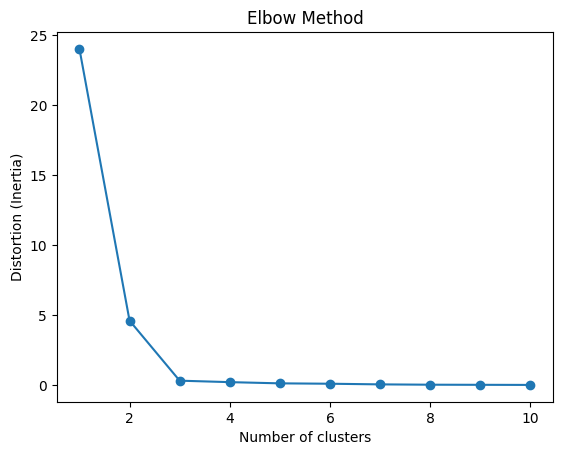

In [ ]:
# エルボー法を実装してみる

distortions = []

# クラスター数を1から10まで変えて計算してみる
for i in range(1, 11):
    km = KMeans(n_clusters=i, random_state=0, n_init=10)
    km.fit(data_scaled) # 前つくった「標準化したデータ」を使用
    distortions.append(km.inertia_) # km.inertia_ が「誤差の総和」

# 結果をグラフにする
plt.plot(range(1, 11), distortions, marker="o")
plt.xlabel("Number of clusters")
plt.ylabel("Distortion (Inertia)")
plt.title("Elbow Method")
plt.show()